In [174]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [175]:
data1 = pd.read_csv('../dataset/Panakkukang.csv')
data2 = pd.read_csv('../dataset/Rappocini.csv')
data3 = pd.read_csv('../dataset/Tallo.csv')
data4 = pd.read_csv('../dataset/Tamalanrea.csv')
data5 = pd.read_csv('../dataset/Tamalate.csv')
data6 = pd.read_csv('../dataset/Ujung Pandang.csv')
data7 = pd.read_csv('../dataset/Ujung Tanah.csv')
data8 = pd.read_csv('../dataset/Wajo.csv')
data9 = pd.read_csv('../dataset/Biringkanaya.csv')
data10 = pd.read_csv('../dataset/Bontoala.csv')
data11 = pd.read_csv('../dataset/Makassar.csv')
data12 = pd.read_csv('../dataset/Mamajang.csv')
data13 = pd.read_csv('../dataset/Manggala.csv')
data14 = pd.read_csv('../dataset/Mariso.csv')


In [176]:
data_clean = pd.concat([data1, data2, data3, data4, data5,data6,data7,data8,data9,data10,data11,data12, data13, data14], ignore_index=True, axis=0).drop_duplicates(ignore_index=True)

In [177]:
data_clean.duplicated().sum()

np.int64(0)

In [178]:
data_clean.isna().sum()

link              0
name              0
rating           74
num_reviewers    74
type              0
dtype: int64

In [179]:
data_clean['num_reviewers'] = data_clean['num_reviewers'].fillna("0")
data_clean['rating'] = data_clean['rating'].fillna(0)

In [180]:
data_clean.isna().sum()

link             0
name             0
rating           0
num_reviewers    0
type             0
dtype: int64

In [181]:
data_clean["num_reviewers"] = data_clean["num_reviewers"].astype(str).str.replace('−', '-', regex=False).str.replace(',', '', regex=False).astype(float).astype(int)*-1

In [182]:
data_clean.drop_duplicates(inplace=True)

In [183]:
data_clean.isna().sum()

link             0
name             0
rating           0
num_reviewers    0
type             0
dtype: int64

In [184]:
data_clean['type'].unique()

array(['Coffee shop', 'Cafe', 'Cafeteria', 'Deli', 'Government office',
       'Coffee store', 'Hobby store', 'Restaurant', 'Store',
       'Espresso bar', 'Coffee roastery', 'Manufacturer', 'Art cafe',
       'Coffee stand', 'Breakfast', 'Dessert', 'Coffee wholesaler',
       'Health and beauty shop', 'Bar', 'Shopping mall', 'Herb shop',
       'Food and beverage exporter', 'Coffee machine supplier',
       'Home goods store', 'Tea house', 'Jl. Sabutung No.144',
       'Cell phone store', 'Seafood', 'Ice Cream', 'Pastries', 'Diner',
       'Traditional market', 'Copy shop', 'Donuts', 'Convenience store',
       'Cendol restaurant', 'Grocery store', 'Housing complex', 'Asian',
       'Indonesian', 'Manado restaurant'], dtype=object)

In [185]:
remove_type = ['Hobby store', 'Deli', 'Coffee machine supplier', 'Shopping mall', 'Herb shop', 'Home goods store',
               'Tea house', 'Cell phone store', 'Seafood', 'Ice Cream', 'Pastries', 'Diner',
               'Traditional market', 'Copy shop', 'Donuts', 'Convenience store', 'Cendol restaurant',
               'Grocery store','Hobby store', 'Coffee roastery', 'Government office', 'Manufacturer', 'Dessert',
               'Jl. Sabutung No.144', 'Health and beauty shop']

In [186]:
# remove value in weird category
data_clean = data_clean[~data_clean['type'].isin(remove_type)]


In [187]:
data_clean['type'].unique()

array(['Coffee shop', 'Cafe', 'Cafeteria', 'Coffee store', 'Restaurant',
       'Store', 'Espresso bar', 'Art cafe', 'Coffee stand', 'Breakfast',
       'Coffee wholesaler', 'Bar', 'Food and beverage exporter',
       'Housing complex', 'Asian', 'Indonesian', 'Manado restaurant'],
      dtype=object)

In [188]:
# regex
pattern = r"3d(-?\d+\.?\d*)!4d(-?\d+\.?\d*)!"

data_clean[['lat', 'long']] = data_clean['link'].str.extract(pattern)

In [189]:
data_clean

,link,name,rating,num_reviewers,type,lat,long
0,https://www.google.com/maps/place/Kopi+Teori+N...,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.1552828,119.4401047
1,https://www.google.com/maps/place/Kopikost+-+C...,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.1444941,119.452607
2,https://www.google.com/maps/place/Melos+Coffee...,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.1354544,119.434586
3,https://www.google.com/maps/place/Institut+KOP...,Institut KOPI,4.7,183,Coffee shop,-5.1543094,119.4391305
4,https://www.google.com/maps/place/Postropis+Co...,Postropis Coffee & Space,4.8,81,Coffee shop,-5.1329919,119.4332702
...,...,...,...,...,...,...,...
1422,https://www.google.com/maps/place/Heavan+With+...,Heavan With You,4.6,436,Cafe,-5.1614779,119.4115125
1423,https://www.google.com/maps/place/Biz+Coffee/d...,Biz Coffee,0.0,0,Coffee shop,-5.1595148,119.4134524
1424,https://www.google.com/maps/place/The+Julu+Ati...,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.1635017,119.4067696
1425,https://www.google.com/maps/place/Kedai+zahra+...,Kedai zahra (coffee & tea,5.0,3,Cafe,-5.1622906,119.4099989


In [190]:
data_clean =data_clean.drop(['link'], axis=1)

In [191]:
data_clean.to_csv("../dataset/data.csv")

### Cleaning reverse geocoded data

In [192]:
rgeo_data = pd.read_csv('../dataset/rgeo-data.csv')

In [193]:
rgeo_data.columns

Index(['X', 'name...2', 'rating', 'num_reviewers', 'type...5', 'lat', 'long',
       'address', 'place_id', 'licence', 'osm_type', 'osm_id', 'osm_lat',
       'osm_lon', 'class', 'type...16', 'place_rank', 'importance',
       'addresstype', 'name...20', 'amenity', 'road', 'hamlet', 'suburb',
       'city_district', 'city', 'state', 'ISO3166-2-lvl4', 'region',
       'ISO3166-2-lvl3', 'postcode', 'country', 'country_code', 'boundingbox',
       'residential', 'shop', 'tourism', 'commercial', 'house_number',
       'building', 'district', 'office', 'village', 'retail', 'neighbourhood',
       'leisure', 'historic', 'municipality', 'town', 'county', 'man_made',
       'place', 'industrial', 'healthcare', 'city_block'],
      dtype='object')

In [194]:
cols = ['name...2', 'rating', 'num_reviewers', 'type...5', 'lat', 'long', 'address', 'suburb', 'city_district', 'city']

In [195]:
data_clean = rgeo_data[cols]

In [196]:
data_clean.columns = ['nama', 'rating', 'jumlah_reviewer', 'tipe', 'lat', 'long', 'alamat', 'kelurahan', 'kecamatan', 'kota']

In [197]:
data_clean['kota'].unique()

array(['Makassar', 'Palopo', nan, 'Jakarta Pusat'], dtype=object)

In [198]:
data_clean[data_clean['kota'].isna()]

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
495,Mo Kopi,5.0,3,Coffee shop,-5.196770,119.399585,"Benteng Somba Opu, Barombong, Gowa, Sulawesi S...",Barombong,NaN,NaN
592,Kopi Saji,4.4,28,Cafe,-5.198123,119.447278,"Ganesha Operation, Jalan Tumanurung, Pandang-P...",NaN,NaN,NaN
596,kedai kopi ujung,5.0,5,Coffee shop,-5.199243,119.473251,"Paccinongang, Somba Opu, Gowa, Sulawesi Selata...",NaN,NaN,NaN
626,UJUNG SUDUT PANDANG CAFE,5.0,2,Coffee shop,-4.029383,122.989631,"Langara, Konawe Kepulauan, Sulawesi Tenggara, ...",NaN,NaN,NaN
707,NgunjukKopi & Kuliner,4.3,57,Espresso bar,-5.195711,119.468947,"Jalan Manggarupi, Green Sabrina Permai, Paccin...",NaN,NaN,NaN
730,Garden Coffee,4.7,123,Coffee shop,-4.145551,120.032284,"Jalan Andi Tanjong, Wajo, Sengkang, Sulawesi S...",NaN,NaN,NaN
731,Toko Kopi Wijaya Kusuma,5.0,19,Coffee shop,-4.140021,120.033204,"Wajo, Padduppa, Sulawesi Selatan, Sulawesi, 90...",NaN,NaN,NaN
732,Kopte Tarik Sengkang Wajo (Kopi & Teh),4.9,21,Coffee shop,-4.132623,120.029563,"Wajo, Teddaopu, Sulawesi Selatan, Sulawesi, 90...",NaN,NaN,NaN
733,Mokopi coffee,4.4,85,Espresso bar,-4.133262,120.028942,"Jalan Jenderal Sudirman, Wajo, Teddaopu, Sulaw...",NaN,NaN,NaN
734,Toko Kopi Seiju,5.0,7,Coffee shop,-4.142130,120.031119,"Jalan Andi Pallawarukka, Wajo, Padduppa, Sulaw...",NaN,NaN,NaN


In [199]:
data_clean[data_clean['kota'] == 'Palopo']

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
218,Kopi Koma Palopo,5.0,41,Coffee shop,-3.009336,120.207358,"Jalan Andi Mappanyompa, Amassangan, Palopo, Su...",NaN,NaN,Palopo
747,Kopi Ko'ui,4.8,388,Coffee shop,-2.990890,120.186058,"Jalan Tandipau, Batupasi, Palopo, Sulawesi Sel...",NaN,NaN,Palopo
750,Figura Kopi,4.9,32,Coffee shop,-3.007053,120.197109,"Pontap, Palopo, Sulawesi Selatan, Sulawesi, 91...",NaN,NaN,Palopo
764,Kopi ruko tua,5.0,5,Coffee shop,-2.997084,120.196410,"Jalan Andi Djemma, Pontap, Palopo, Sulawesi Se...",NaN,NaN,Palopo
795,Kampoeng ponjalae kopi,5.0,1,Coffee shop,-2.989256,120.204324,"Jalan Abdulla Dg. Mappuji, Pontap, Palopo, Sul...",NaN,NaN,Palopo
832,Kopi Konspirasi,5.0,2,Coffee shop,-2.990560,120.186846,"Jalan Doktor Ratulangi, Pontap, Palopo, Sulawe...",NaN,NaN,Palopo


In [200]:
data_clean[data_clean['kota'] == 'Jakarta Pusat']

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
1245,Manggala Resto & Cafe,5.0,5,Restaurant,-6.207283,106.799757,"Kompleks Parlemen, RW 01, Gelora, Tanah Abang,...",Tanah Abang,NaN,Jakarta Pusat


In [201]:
remove_kota = ['Palopo', 'Jakarta Pusat', np.nan]

In [202]:
data_clean = data_clean[~data_clean['kota'].isin(remove_kota)]

In [203]:
data_clean['kota'].unique()

array(['Makassar'], dtype=object)

In [204]:
data_clean['kecamatan'].unique()

array(['Panakkukang', 'Rappocini', 'Ujung Pandang', 'Mamajang', nan,
       'Tamalate', 'Makassar', 'Tallo', 'Ujung Tanah', 'Bontoala',
       'Biringkanaya', 'Mariso', 'Wajo', 'Kepulauan Sangkarrang'],
      dtype=object)

In [205]:
nan_kecamatan = data_clean[data_clean['kecamatan'].isna()]
nan_kecamatan['kelurahan'].unique()

array(['Borong', 'Tamangapa', 'Tamalanrea', 'Buntusu', 'Tamalanrea Indah',
       'Kapasa', 'Tamalanrea Jaya', 'Bira', 'Biring Romang', 'Moncongloe',
       'Antang', 'Manggala', nan, 'Bangkala', 'Bitoa', 'Batua', 'Paropo'],
      dtype=object)

In [206]:
kel_manggala = ['Antang', 'Bangkala', 'Batua', 'Biring Romang', 'Bitowa','Bitoa', 'Borong', 'Manggala', 'Tamangapa', np.nan]
data_clean.loc[data_clean['kelurahan'].isin(kel_manggala), 'kecamatan'] = "Manggala"


In [207]:
data_clean[data_clean['kecamatan'] == "Manggala"]

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
71,Sains kopi,4.8,55,Coffee shop,-5.166524,119.453403,"Panakkukang Permai, Borong, Manggala, Makassar...",Borong,Manggala,Makassar
201,MAKO (markas kopi ),4.7,20,Coffee shop,-5.169711,119.458304,"Jalan Borong Indah, Puri Taman Sari, Borong, M...",Borong,Manggala,Makassar
283,TABIKinKOPI,5.0,4,Coffee shop,-5.185234,119.489774,"Kassik, Tamangapa, Manggala, Makassar, Sulawes...",Tamangapa,Manggala,Makassar
511,Kopi Tama Antang,4.8,29,Cafeteria,-5.168458,119.492279,"Jalan Lasuloro Dalam 7, Biring Romang, Manggal...",Biring Romang,Manggala,Makassar
549,Mooka kopi Antang,4.3,19,Food and beverage exporter,-5.167344,119.479250,"Jalan Tamangapa Raya, Tamanngapa, Biring Roman...",Biring Romang,Manggala,Makassar
...,...,...,...,...,...,...,...,...,...,...
1248,Kedai Kopi & Roti Canai Borneo,3.3,3,Coffee shop,-5.157690,119.487086,"Jalan Raya Baruga, Bukit Baruga, Bukit Batu, A...",Antang,Manggala,Makassar
1249,Warkop Azzahrah - Tamangapa,4.6,7,Coffee shop,-5.171274,119.479590,"Jalan Tamangapa Raya, Tamanngapa, Bangkala, Ma...",Bangkala,Manggala,Makassar
1250,Kopi Sejoli,5.0,2,Cafe,-5.159554,119.461206,"Jalan Batua Raya XIV, Batua, Manggala, Makassa...",Batua,Manggala,Makassar
1251,Space Garage,5.0,20,Cafe,-5.150632,119.467553,"Jalan Toa Daeng I, Toa Daeng, Batua, Manggala,...",NaN,Manggala,Makassar


In [208]:
kel_tamalanrea = ['Bira', 'Buntusu', 'Kapasa', 'Kapasa Raya', 'Parangloe', 'Tamalanrea', 'Tamalanrea Indah', 'Tamalanrea Jaya']
data_clean.loc[data_clean['kelurahan'].isin(kel_tamalanrea), 'kecamatan'] = "Tamalanrea"


In [209]:
data_clean.loc[data_clean['kelurahan'].isin(['Paropo']), 'kecamatan'] = "Panakkukang"

In [210]:
# remove data not in makassar
data_clean = data_clean[~data_clean['kelurahan'].isin(['Moncongloe'])]

In [211]:
nan_kecamatan = data_clean[data_clean['kecamatan'].isna()]
nan_kecamatan['kelurahan'].unique()

array([], dtype=object)

In [212]:
data_clean[data_clean['kelurahan'].isna()]

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
1147,Teteskopi,4.6,107,Coffee shop,-5.150076,119.475372,"Jalan Inspeksi Pam, Tellok, Batua, Manggala, M...",NaN,Manggala,Makassar
1149,Hop.in Coffee,4.8,39,Coffee shop,-5.159690,119.459428,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1155,Interferon Class Cafe,4.8,38,Coffee shop,-5.150381,119.470342,"Tellok, Batua, Manggala, Makassar, Sulawesi Se...",NaN,Manggala,Makassar
1157,CAFE DOMINO MAKASSAR,4.8,61,Coffee shop,-5.151107,119.476974,"Jalan Inspeksi Pam, Tellok, Batua, Manggala, M...",NaN,Manggala,Makassar
1159,LAPAK KOPI MAKASSAR,4.8,39,Cafe,-5.150670,119.472653,"Jalan Inspeksi PAM Lorong 1, Tellok, Batua, Ma...",NaN,Manggala,Makassar
1173,Warung Kopi OGI,4.2,614,Coffee shop,-5.149839,119.464767,"Jalan Abdullah Daeng Sirua, Bonto Bila, Batua,...",NaN,Manggala,Makassar
1175,Kedai Kopi Panacea,4.8,18,Coffee shop,-5.156033,119.458742,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1176,T4 Minum Kopi LaFeGa,4.5,19,Coffee shop,-5.154210,119.458828,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1188,Point Coffee,4.5,71,Coffee shop,-5.151173,119.460493,"Indomart, Jalan Batua Raya, Batua, Bonto Bila,...",NaN,Manggala,Makassar
1190,Coffee Aroma Doloe,5.0,4,Cafe,-5.149941,119.464381,"EZ Laundry, 353a, Jalan Abdullah Daeng Sirua, ...",NaN,Manggala,Makassar


In [213]:
data_kel_nan = data_clean[data_clean['kelurahan'].isna()]
for i, data in data_kel_nan.iterrows():
    print(data['rating'])

4.6
4.8
4.8
4.8
4.8
4.2
4.8
4.5
4.5
5.0
5.0
4.4
5.0
5.0
4.3
4.8
0.0
5.0


In [214]:
data_clean.loc[1147]

nama                                                       Teteskopi
rating                                                           4.6
jumlah_reviewer                                                  107
tipe                                                     Coffee shop
lat                                                        -5.150076
long                                                      119.475372
alamat             Jalan Inspeksi Pam, Tellok, Batua, Manggala, M...
kelurahan                                                        NaN
kecamatan                                                   Manggala
kota                                                        Makassar
Name: 1147, dtype: object

In [215]:
data_clean

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
0,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.155283,119.440105,"WARKOP SAMI, Jalan Boulevard, Masale, Panakkuk...",Masale,Panakkukang,Makassar
1,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.144494,119.452607,"Profesor Abdurrahman Basalamah, Karampuang, Pa...",Karampuang,Panakkukang,Makassar
2,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.135454,119.434586,"Jalan Perkebunan, Sinrijala, Panakkukang, Maka...",Sinrijala,Panakkukang,Makassar
3,Institut KOPI,4.7,183,Coffee shop,-5.154309,119.439131,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar
4,Postropis Coffee & Space,4.8,81,Coffee shop,-5.132992,119.433270,"Jalan Adipura Raya, Tamajeʼneʼ, Karuwisi Utara...",Karuwisi Utara,Panakkukang,Makassar
...,...,...,...,...,...,...,...,...,...,...
1351,Heavan With You,4.6,436,Cafe,-5.161478,119.411513,"Jalan K.S. Tubun, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar
1352,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar
1353,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar
1354,Kedai zahra (coffee & tea,5.0,3,Cafe,-5.162291,119.409999,"Jalan Hati Mulia, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar


In [216]:
data_kel_nan

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
1147,Teteskopi,4.6,107,Coffee shop,-5.150076,119.475372,"Jalan Inspeksi Pam, Tellok, Batua, Manggala, M...",NaN,Manggala,Makassar
1149,Hop.in Coffee,4.8,39,Coffee shop,-5.159690,119.459428,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1155,Interferon Class Cafe,4.8,38,Coffee shop,-5.150381,119.470342,"Tellok, Batua, Manggala, Makassar, Sulawesi Se...",NaN,Manggala,Makassar
1157,CAFE DOMINO MAKASSAR,4.8,61,Coffee shop,-5.151107,119.476974,"Jalan Inspeksi Pam, Tellok, Batua, Manggala, M...",NaN,Manggala,Makassar
1159,LAPAK KOPI MAKASSAR,4.8,39,Cafe,-5.150670,119.472653,"Jalan Inspeksi PAM Lorong 1, Tellok, Batua, Ma...",NaN,Manggala,Makassar
1173,Warung Kopi OGI,4.2,614,Coffee shop,-5.149839,119.464767,"Jalan Abdullah Daeng Sirua, Bonto Bila, Batua,...",NaN,Manggala,Makassar
1175,Kedai Kopi Panacea,4.8,18,Coffee shop,-5.156033,119.458742,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1176,T4 Minum Kopi LaFeGa,4.5,19,Coffee shop,-5.154210,119.458828,"Jalan Batua Raya, Batua, Bonto Bila, Batua, Ma...",NaN,Manggala,Makassar
1188,Point Coffee,4.5,71,Coffee shop,-5.151173,119.460493,"Indomart, Jalan Batua Raya, Batua, Bonto Bila,...",NaN,Manggala,Makassar
1190,Coffee Aroma Doloe,5.0,4,Cafe,-5.149941,119.464381,"EZ Laundry, 353a, Jalan Abdullah Daeng Sirua, ...",NaN,Manggala,Makassar


In [217]:
# impute Nan value with reverse geocode
from geopy.geocoders import Nominatim

data_kel_nan = data_clean[data_clean['kelurahan'].isna()]
geolocator = Nominatim(user_agent="orienternet")

for i, row in data_kel_nan.iterrows():
    lat, long = row[['lat', 'long']]
    location = geolocator.reverse(f"{lat}, {long}")
    data_clean.loc[i, 'kelurahan'] = location.raw.get('address').get('hamlet')

GeocoderUnavailable: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=-5.1500756&lon=119.4753722&format=json&addressdetails=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))

In [ ]:
data_clean.to_csv('../dataset/data_clean.csv', index=False)

OSError: Cannot save file into a non-existent directory: 'dataset'

In [ ]:
data_clean

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
0,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.155283,119.440105,"WARKOP SAMI, Jalan Boulevard, Masale, Panakkuk...",Masale,Panakkukang,Makassar
1,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.144494,119.452607,"Profesor Abdurrahman Basalamah, Karampuang, Pa...",Karampuang,Panakkukang,Makassar
2,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.135454,119.434586,"Jalan Perkebunan, Sinrijala, Panakkukang, Maka...",Sinrijala,Panakkukang,Makassar
3,Institut KOPI,4.7,183,Coffee shop,-5.154309,119.439131,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar
4,Postropis Coffee & Space,4.8,81,Coffee shop,-5.132992,119.433270,"Jalan Adipura Raya, Tamajeʼneʼ, Karuwisi Utara...",Karuwisi Utara,Panakkukang,Makassar
...,...,...,...,...,...,...,...,...,...,...
1351,Heavan With You,4.6,436,Cafe,-5.161478,119.411513,"Jalan K.S. Tubun, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar
1352,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar
1353,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar
1354,Kedai zahra (coffee & tea,5.0,3,Cafe,-5.162291,119.409999,"Jalan Hati Mulia, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar


In [ ]:
data_clean.isna().sum()

nama               0
rating             0
jumlah_reviewer    0
tipe               0
lat                0
long               0
alamat             0
kelurahan          0
kecamatan          0
kota               0
dtype: int64

<Axes: xlabel='jumlah_reviewer', ylabel='rating'>

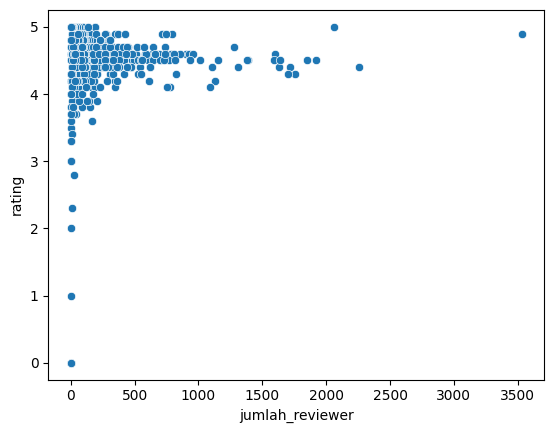

In [ ]:
sns.scatterplot(data_clean, x="jumlah_reviewer", y="rating" )

In [ ]:
data_clean.describe()

,rating,jumlah_reviewer,lat,long
count,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.463969,106.445038,-5.144628,119.443451
std,1.040912,252.004550,0.023291,0.035453
min,0.000000,0.000000,-5.214848,119.327802
25%,4.500000,5.000000,-5.161365,119.417357
50%,4.700000,21.000000,-5.148688,119.431002
75%,5.000000,89.000000,-5.126659,119.458473
max,5.000000,3530.000000,-5.048941,119.531709


In [ ]:
def calculate_bayesian_rating(df):
    C = np.nanmean(df['rating'].values)
    m = np.mean(df['jumlah_reviewer'].values)

    bayesian_rating = ((m * C) + (df["jumlah_reviewer"] * df["rating"]) ) / (m + df["jumlah_reviewer"])

    return bayesian_rating

In [ ]:
data_eda = data_clean.copy()

In [ ]:
data_eda['bayesian_rating'] = calculate_bayesian_rating(data_eda)

print(pd.DataFrame(data_eda))

                              nama  rating  jumlah_reviewer         tipe  \
0           Kopi Teori New Chapter     4.7              452  Coffee shop   
1     Kopikost - Coffee & Roastery     4.6              128  Coffee shop   
2            Melos Coffee & Eatery     4.3              311  Coffee shop   
3                    Institut KOPI     4.7              183  Coffee shop   
4         Postropis Coffee & Space     4.8               81  Coffee shop   
...                            ...     ...              ...          ...   
1351               Heavan With You     4.6              436         Cafe   
1352                    Biz Coffee     0.0                0  Coffee shop   
1353  The Julu Ati Coffee & Garden     0.0                0  Coffee shop   
1354     Kedai zahra (coffee & tea     5.0                3         Cafe   
1355                      Teras Ai     0.0                0  Coffee shop   

           lat        long                                             alamat  \
0    -

In [ ]:
idx=np.argmax(data_eda['bayesian_rating'])

In [ ]:
data_eda.iloc[idx]

nama                       Babathe X Luce Nusantara resto and gelato
rating                                                           5.0
jumlah_reviewer                                                 2065
tipe                                                            Cafe
lat                                                        -5.126891
long                                                      119.408432
alamat             Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...
kelurahan                                                       Ende
kecamatan                                                       Wajo
kota                                                        Makassar
bayesian_rating                                             4.973724
Name: 679, dtype: object

In [ ]:
data_eda

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating
0,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.155283,119.440105,"WARKOP SAMI, Jalan Boulevard, Masale, Panakkuk...",Masale,Panakkukang,Makassar,4.655010
1,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.144494,119.452607,"Profesor Abdurrahman Basalamah, Karampuang, Pa...",Karampuang,Panakkukang,Makassar,4.538238
2,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.135454,119.434586,"Jalan Perkebunan, Sinrijala, Panakkukang, Maka...",Sinrijala,Panakkukang,Makassar,4.341811
3,Institut KOPI,4.7,183,Coffee shop,-5.154309,119.439131,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar,4.613198
4,Postropis Coffee & Space,4.8,81,Coffee shop,-5.132992,119.433270,"Jalan Adipura Raya, Tamajeʼneʼ, Karuwisi Utara...",Karuwisi Utara,Panakkukang,Makassar,4.609177
...,...,...,...,...,...,...,...,...,...,...,...
1351,Heavan With You,4.6,436,Cafe,-5.161478,119.411513,"Jalan K.S. Tubun, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar,4.573306
1352,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar,4.463969
1353,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar,4.463969
1354,Kedai zahra (coffee & tea,5.0,3,Cafe,-5.162291,119.409999,"Jalan Hati Mulia, Kampung Buyang, Mariso, Maka...",Kampung Buyang,Mariso,Makassar,4.478663


## **Bayesian Rating**

In [ ]:
data_sorted = data_eda.sort_values(['bayesian_rating'], ascending=False)
data_sorted.head(8)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating
679,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar,4.973724
790,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar,4.887237
1032,Cocospace Cafe,4.9,796,Cafe,-5.151853,119.420294,"Barts Goods (@barts.goods), No. 25b, Jalan Lan...",Maricaya,Makassar,Makassar,4.848569
1039,Kedai Lawas Monginsidi,4.9,746,Coffee shop,-5.148787,119.423405,"Jalan Monginsidi, Maricaya Baru, Makassar, Sul...",Maricaya Baru,Makassar,Makassar,4.845553
12,Squid Coffee,4.9,715,Coffee shop,-5.154581,119.441044,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar,4.843498
1106,Chatime,4.9,425,Coffee shop,-5.152607,119.417753,"Mall Ratu Indah, Jalan Sam Ratulangi, Mamajang...",Mamajang Luar,Mamajang,Makassar,4.812666
530,Houslatte Sungai Saddang,5.0,194,Cafe,-5.146254,119.422566,"Sawawa Advertising, 70, Jalan Sungai Saddang L...",Maradekaya Selatan,Makassar,Makassar,4.810089
545,Houslatte Grestelina,5.0,190,Coffee shop,-5.162872,119.445681,"Rumah Sakit Grestelina, Jalan Toddopuli II, Pa...",Pandang,Panakkukang,Makassar,4.807527


- **Babathe X Luce Nusantara resto and gelato** menjadi tempat nongkrong yang paling disukai warga Kota Makassar dengan nilai bayesian rating yaitu **4.973687**

#### **Market leader**

In [ ]:
data_eda.sort_values(['jumlah_reviewer'], ascending=False)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating
790,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar,4.887237
861,Warkop Five One,4.4,2254,Coffee shop,-5.119632,119.509392,"warkop 51, Jalan Puri Yuhana, Puri Yuhana Perm...",Daya,Biringkanaya,Makassar,4.402885
679,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar,4.973724
947,Warkop Azzahrah - Bandang,4.5,1920,Coffee shop,-5.122904,119.418671,"Warkop Az-zarah, Jalan Bandang I, Parang Layan...",Parang Layang,Bontoala,Makassar,4.498107
582,Es Putar Papabon,4.5,1849,Coffee shop,-5.140735,119.409328,"Jalan Dg. Tompo, Maloku, Ujung Pandang, Makass...",Maloku,Ujung Pandang,Makassar,4.498039
...,...,...,...,...,...,...,...,...,...,...,...
1326,Daico,0.0,0,Coffee shop,-5.159188,119.407646,"Mariso, Makassar, Sulawesi Selatan, Sulawesi, ...",Mariso,Mariso,Makassar,4.463969
1352,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar,4.463969
1353,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar,4.463969
1329,Kopi lounge,0.0,0,Coffee shop,-5.160624,119.407959,"Jalan Seruni, Kampung Buyang, Mariso, Makassar...",Kampung Buyang,Mariso,Makassar,4.463969


In [ ]:
data_sorted.head(10)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating
679,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar,4.973724
790,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar,4.887237
1032,Cocospace Cafe,4.9,796,Cafe,-5.151853,119.420294,"Barts Goods (@barts.goods), No. 25b, Jalan Lan...",Maricaya,Makassar,Makassar,4.848569
1039,Kedai Lawas Monginsidi,4.9,746,Coffee shop,-5.148787,119.423405,"Jalan Monginsidi, Maricaya Baru, Makassar, Sul...",Maricaya Baru,Makassar,Makassar,4.845553
12,Squid Coffee,4.9,715,Coffee shop,-5.154581,119.441044,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar,4.843498
1106,Chatime,4.9,425,Coffee shop,-5.152607,119.417753,"Mall Ratu Indah, Jalan Sam Ratulangi, Mamajang...",Mamajang Luar,Mamajang,Makassar,4.812666
530,Houslatte Sungai Saddang,5.0,194,Cafe,-5.146254,119.422566,"Sawawa Advertising, 70, Jalan Sungai Saddang L...",Maradekaya Selatan,Makassar,Makassar,4.810089
545,Houslatte Grestelina,5.0,190,Coffee shop,-5.162872,119.445681,"Rumah Sakit Grestelina, Jalan Toddopuli II, Pa...",Pandang,Panakkukang,Makassar,4.807527
1057,Djournal Coffee - Trans Studio Makassar,4.9,371,Coffee shop,-5.159209,119.394277,"my Kopi O!, Jalan Metro Tanjung Bunga, Maccini...",Maccini Sombala,Tamalate,Makassar,4.802788
9,Pojok kopi topaz,4.9,344,Coffee shop,-5.154023,119.439817,"Panembahan Adiwisata Tour, Jalan Topaz Raya, M...",Masale,Panakkukang,Makassar,4.796961


In [ ]:
data_sorted.to_csv("dataset/ranked_data.csv")

In [ ]:
print(data_clean)   

                              nama  rating  jumlah_reviewer         tipe  \
0           Kopi Teori New Chapter     4.7              452  Coffee shop   
1     Kopikost - Coffee & Roastery     4.6              128  Coffee shop   
2            Melos Coffee & Eatery     4.3              311  Coffee shop   
3                    Institut KOPI     4.7              183  Coffee shop   
4         Postropis Coffee & Space     4.8               81  Coffee shop   
...                            ...     ...              ...          ...   
1351               Heavan With You     4.6              436         Cafe   
1352                    Biz Coffee     0.0                0  Coffee shop   
1353  The Julu Ati Coffee & Garden     0.0                0  Coffee shop   
1354     Kedai zahra (coffee & tea     5.0                3         Cafe   
1355                      Teras Ai     0.0                0  Coffee shop   

           lat        long                                             alamat  \
0    -